# **Sales and Inventory Analysis**

> This analysis is part of a portfolio for data/business analyst roles (and related fields), created by Khalila Izzatunnisa.

> For further information about dataset, visit https://www.kaggle.com/datasets/bhanupratapbiswas/inventory-analysis-case-study.

In [5]:
# Import data
import pandas as pd

# This is a master data for store and product
store = pd.read_csv('https://docs.google.com/spreadsheets/d/1aVJwLSaZGzFCiupMPp_yOHLf_8Bh6oKFX_8Y_rh2H9E/export?format=csv')
product = pd.read_csv('https://docs.google.com/spreadsheets/d/1P1V5NAsyY_XzEM9r1yYHSrJeiDBLDpfk3wByR1f3LtA/export?format=csv')

# Assume we just passed January and about to make end-of-month report
# These datasets are integrated from all store and city
# Load data with its original format
# Begin: Beginning inventory data (or ending inventory data from last month)
begin = pd.read_csv('/content/BeginJan16.csv', sep=None, engine='python')

# Purchase: Purchase data
purchase = pd.read_csv('/content/PurchaseJan16.csv', sep=None, engine='python')

# Sales: Sales data
sales = pd.read_csv('/content/SalesJan16.csv', sep=None, engine='python')

In [8]:
# Data preparation to maintain consistency
# Overwrite description and size in other table referring to product master data
begin['Description'] = begin['Brand'].map(product.set_index('Brand')['Description'])
begin['Size'] = begin['Brand'].map(product.set_index('Brand')['Size'])
purchase['Description'] = purchase['Brand'].map(product.set_index('Brand')['Description'])
purchase['Size'] = purchase['Brand'].map(product.set_index('Brand')['Size'])
sales['Description'] = sales['Brand'].map(product.set_index('Brand')['Description'])
sales['Size'] = sales['Brand'].map(product.set_index('Brand')['Size'])

# Create city column and look up value from store master data
purchase['City'] = purchase['Store'].map(store.set_index('Store')['City'])
sales['City'] = sales['Store'].map(store.set_index('Store')['City'])

# Rename column
sales.rename(columns={'SalesDollars': 'Revenue', 'VendorNo': 'VendorNumber'}, inplace=True)
purchase.rename(columns={'Quantity': 'PurchaseQuantity', 'Dollars': 'PurchaseCost'}, inplace=True)

# Change type to datetime
begin['startDate'] = pd.to_datetime(begin['startDate'], errors='coerce', dayfirst=True)
purchase['PODate'] = pd.to_datetime(purchase['PODate'], errors='coerce', dayfirst=True)
purchase['ReceivingDate'] = pd.to_datetime(purchase['ReceivingDate'],  errors='coerce', dayfirst=True)
purchase['InvoiceDate'] = pd.to_datetime(purchase['InvoiceDate'], errors='coerce', dayfirst=True)
purchase['PayDate'] = pd.to_datetime(purchase['PayDate'], errors='coerce', dayfirst=True)
sales['SalesDate'] = pd.to_datetime(sales['SalesDate'], errors='coerce', dayfirst=True)

# Create helper column
# StoreId: Merge from Store + City
begin['StoreId'] = begin['Store'].astype(str) + '_' + begin['City']
purchase['StoreId'] = purchase['Store'].astype(str)  + '_' + purchase['City']
sales['StoreId'] = sales['Store'].astype(str)  + '_' + sales['City']

# PurchasePrice in sales table: To calculate COGS and profit
sales['PurchasePrice'] = sales['Brand'].map(product.set_index('Brand')['PurchasePrice'])

In [16]:
sales

,InventoryId,Store,Brand,Description,Size,SalesQuantity,Revenue,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNumber,VendorName,City,StoreId,PurchasePrice
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2016-01-01,750,1,0.79,12546,JIM BEAM BRANDS COMPANY,HARDERSFIELD,1_HARDERSFIELD,10.65
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2016-01-02,750,1,1.57,12546,JIM BEAM BRANDS COMPANY,HARDERSFIELD,1_HARDERSFIELD,10.65
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2016-01-03,750,1,0.79,12546,JIM BEAM BRANDS COMPANY,HARDERSFIELD,1_HARDERSFIELD,10.65
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,2016-01-08,750,1,0.79,12546,JIM BEAM BRANDS COMPANY,HARDERSFIELD,1_HARDERSFIELD,10.65
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,2016-01-09,375,1,0.79,12546,JIM BEAM BRANDS COMPANY,HARDERSFIELD,1_HARDERSFIELD,27.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
937591,9_BLACKPOOL_984,9,984,Patron XO Cafe Liqueur,750mL,1,26.99,26.99,2016-01-04,750,1,0.79,9165,ULTRA BEVERAGE COMPANY LLP,BLACKPOOL,9_BLACKPOOL,20.63
937592,9_BLACKPOOL_984,9,984,Patron XO Cafe Liqueur,750mL,1,26.99,26.99,2016-01-15,750,1,0.79,9165,ULTRA BEVERAGE COMPANY LLP,BLACKPOOL,9_BLACKPOOL,20.63
937593,9_BLACKPOOL_984,9,984,Patron XO Cafe Liqueur,750mL,1,26.99,26.99,2016-01-17,750,1,0.79,9165,ULTRA BEVERAGE COMPANY LLP,BLACKPOOL,9_BLACKPOOL,20.63
937594,9_BLACKPOOL_984,9,984,Patron XO Cafe Liqueur,750mL,1,26.99,26.99,2016-01-19,750,1,0.79,9165,ULTRA BEVERAGE COMPANY LLP,BLACKPOOL,9_BLACKPOOL,20.63


In [30]:
# Create derived columns for basic calculations
# Cost of goods sold (COGS)
sales['COGS'] = sales['SalesQuantity'] * sales['PurchasePrice']

# Profit
sales['Profit'] = sales['Revenue'] - sales['COGS']

## Generate Summary Data

### Total Order Quantity, Revenue, Profit, and Gross Margin by Store

In [31]:
# Calculate total order quantity, revenue, profit, and gross margin
order_qty = sales['SalesQuantity'].sum()
revenue = sales['Revenue'].sum()
profit = sales['Profit'].sum()
gross_margin_percent = profit / revenue

# Calculate total sales quantity, revenue, and profit group by StoreId
sales_summary = sales.groupby('StoreId').agg({'SalesQuantity': 'sum', 'Revenue': 'sum', 'Profit': 'sum'}).reset_index()

# Calculate gross margin percent
sales_summary['GrossMargin%'] = sales_summary['Profit'] / sales_summary['Revenue'] * 100

# Calculate revenue and profit contribution to total revenue and total profit
sales_summary['RevenueContribution%'] = sales_summary['Revenue'] / sales_summary['Revenue'].sum() * 100
sales_summary['ProfitContribution%'] = sales_summary['Profit'] / sales_summary['Profit'].sum() * 100

# Show result and sort by revenue from highest to lowest
# First row is top revenue contributing store
print('Total Order Quantity:', order_qty)
print('Total Revenue:', revenue)
print('Total Profit:', profit)
print(f"Gross Margin Percent: {gross_margin_percent:.2f}")
sales_summary.sort_values('Revenue', ascending=False)

Total Order Quantity: 2194959
Total Revenue: 29854027.919999994
Total Profit: 9804439.550000003
Gross Margin Percent: 0.33


,StoreId,SalesQuantity,Revenue,Profit,GrossMargin%,RevenueContribution%,ProfitContribution%
26,34_PITMERDEN,99171,1537806.51,502494.79,32.676074,5.151086,5.125176
72,76_DONCASTER,85724,1402698.59,467097.03,33.299886,4.698524,4.764138
69,73_DONCASTER,77848,1266850.62,420485.10,33.191372,4.243483,4.288721
61,66_EANVERNESS,76814,1257824.93,418387.15,33.262749,4.213250,4.267323
30,38_GOULCREST,84965,1237991.19,415805.79,33.587136,4.146815,4.240995
...,...,...,...,...,...,...,...
8,18_FURNESS,6207,88268.61,28215.93,31.965984,0.295667,0.287787
29,37_PAETHSMOUTH,5359,66599.43,21421.03,32.163984,0.223084,0.218483
20,29_AYLESBURY,4447,46191.93,14973.61,32.416074,0.154726,0.152723
17,26_KNIFE'S EDGE,2642,33599.00,10482.96,31.200214,0.112544,0.106921


In [ ]:
# Save to csv file
sales_summary.to_csv('SalesSummaryJan16.csv', index=False)

### Ending Inventory Data -> Beginning Inventory Data for Next Month

In [40]:
# Create summary data for cash and stock flow group by InventoryId
# Begin, sales and purchase data
summary_begin = begin[['InventoryId', 'onHand']].copy()
summary_sales = sales.groupby('InventoryId').agg(
    TotalSalesQuantity = ('SalesQuantity', 'sum'),
    TotalRevenue = ('Revenue', 'sum'),
    TotalCOGS = ('COGS', 'sum'),
    TotalProfit = ('Profit', 'sum')).reset_index()
summary_purchase = purchase.groupby('InventoryId').agg(
    TotalPurchaseQuantity = ('PurchaseQuantity', 'sum'),
    TotalPurchaseCost = ('PurchaseCost', 'sum')).reset_index()

# Merge data
# Begin and sales data
summary = summary_begin.merge(summary_sales,
    on='InventoryId',
    how='outer'
).fillna(0)
# Begin, sales, and purchase data
summary = summary.merge(summary_purchase,
    on='InventoryId',
    how='outer'
).fillna(0)

# Extract brand and store_id
summary['StoreId'] = summary['InventoryId'].str.split('_', expand=True)[0] + '_' + summary['InventoryId'].str.split('_', expand=True)[1]
summary['Brand'] = summary['InventoryId'].str.split('_', expand=True)[2]
summary['Brand'] = summary['Brand'].astype(int)

# Calculate ending inventory
summary['EndInv'] = summary['onHand'] - summary['TotalSalesQuantity'] + summary['TotalPurchaseQuantity']

# Convert quantity data type to integer
summary['onHand'] = summary['onHand'].astype(int)
summary['TotalSalesQuantity'] = summary['TotalSalesQuantity'].astype(int)
summary['TotalPurchaseQuantity'] = summary['TotalPurchaseQuantity'].astype(int)
summary['EndInv'] = summary['EndInv'].astype(int)

# Show result
summary.head()

,InventoryId,onHand,TotalSalesQuantity,TotalRevenue,TotalCOGS,TotalProfit,TotalPurchaseQuantity,TotalPurchaseCost,StoreId,Brand,EndInv
0,10_HORNSEY_1000,1,1,16.99,11.62,5.37,0,0.00,10_HORNSEY,1000,0
1,10_HORNSEY_1001,11,11,65.89,47.08,18.81,0,0.00,10_HORNSEY,1001,0
2,10_HORNSEY_1005,18,3,104.97,82.02,22.95,0,0.00,10_HORNSEY,1005,15
3,10_HORNSEY_10058,52,6,89.94,55.56,34.38,82,759.32,10_HORNSEY,10058,128
4,10_HORNSEY_1006,1,1,3.99,3.14,0.85,0,0.00,10_HORNSEY,1006,0


In [44]:
# Generate ending inventory data as begin inventory for next month report
end = summary[['InventoryId', 'EndInv']].copy()
end.rename(columns={'EndInv': 'onHand'}, inplace=True)

# Create data by its original format
end['Store'] = end['InventoryId'].str.split('_', expand=True)[0]
end['City'] = end['InventoryId'].str.split('_', expand=True)[1]
end['Brand'] = end['InventoryId'].str.split('_', expand=True)[2]
end['Brand'] = end['Brand'].astype(int)
end['Description'] = end['Brand'].map(product.set_index('Brand')['Description'])
end['Size'] = end['Brand'].map(product.set_index('Brand')['Size'])
end['Price'] = end['Brand'].map(product.set_index('Brand')['Price'])
end['startDate'] = '2016-02-01'

# Rearrange column
end = end[['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'Price', 'onHand', 'startDate']]
end.head()

,InventoryId,Store,City,Brand,Description,Size,Price,onHand,startDate
0,10_HORNSEY_1000,10,HORNSEY,1000,Goslings Dark'n Stormy VAP,750mL,14.99,0,2016-02-01
1,10_HORNSEY_1001,10,HORNSEY,1001,Bailey's 50mL 4 Pack,50mL 4 Pk,5.99,0,2016-02-01
2,10_HORNSEY_1005,10,HORNSEY,1005,Maker's Mark Combo Pack,375mL 2 Pk,34.99,15,2016-02-01
3,10_HORNSEY_10058,10,HORNSEY,10058,F Coppola Dmd Ivry Cab Svgn,750mL,13.99,128,2016-02-01
4,10_HORNSEY_1006,10,HORNSEY,1006,Jim Beam Candy Cane 4/50mLs,50mL 4 Pk,3.99,0,2016-02-01


In [ ]:
# Save to csv file
end.to_csv('BeginFeb16.csv', index=False)

### [FILTERED BY STORE] Total Order Quantity, Revenue, and Profit by Product

In [45]:
# This summary is generated for single store only (not globally/entire franchise)
# Filter format 'Store_City'
store_id = '34_PITMERDEN'

In [46]:
# Create begin, sales and purchase subset data for selected store
summary_store = summary[summary['StoreId'] == store_id]
purchase_store = purchase[purchase['StoreId'] == store_id]

In [50]:
# Create summary data for cash and stock flow
store_summary = summary_store.groupby('Brand').agg(
    TotalSalesQuantity = ('TotalSalesQuantity', 'sum'),
    TotalRevenue = ('TotalRevenue', 'sum'),
    TotalCOGS = ('TotalCOGS', 'sum'),
    TotalProfit = ('TotalProfit', 'sum'),
    TotalPurchaseQuantity = ('TotalPurchaseQuantity', 'sum'),
    TotalPurchaseCost = ('TotalPurchaseCost', 'sum')).reset_index()

# Create store_id column
store_summary['StoreId'] = store_id

# Look up description and size column
store_summary['Description'] = store_summary['Brand'].map(product.set_index('Brand')['Description'])
store_summary['Size'] = store_summary['Brand'].map(product.set_index('Brand')['Size'])

# Look up beginning and ending inventory quantity
store_summary['BeginInv'] = store_summary['Brand'].map(summary_store.set_index('Brand')['onHand'])
store_summary['EndInv'] = store_summary['Brand'].map(summary_store.set_index('Brand')['EndInv'])

# Calculate beginning and ending inventory value
store_summary['BeginInvValue'] = store_summary['BeginInv'] * store_summary['Brand'].map(product.set_index('Brand')['PurchasePrice'])
store_summary['EndInvValue'] = store_summary['EndInv'] * store_summary['Brand'].map(product.set_index('Brand')['PurchasePrice'])

# Rearramge column
store_summary = store_summary[['StoreId', 'Brand', 'Description', 'Size', 'BeginInv', 'BeginInvValue', 'TotalSalesQuantity', 'TotalRevenue', 'TotalCOGS', 'TotalProfit', 'TotalPurchaseQuantity', 'TotalPurchaseCost', 'EndInv', 'EndInvValue']]

# Remove records with all values equal to 0 or NaN
store_summary = store_summary.fillna(0)
store_summary

,StoreId,Brand,Description,Size,BeginInv,BeginInvValue,TotalSalesQuantity,TotalRevenue,TotalCOGS,TotalProfit,TotalPurchaseQuantity,TotalPurchaseCost,EndInv,EndInvValue
0,34_PITMERDEN,58,Gekkeikan Black & Gold Sake,750mL,4,37.12,15,194.85,139.20,55.65,12,111.36,1,9.28
1,34_PITMERDEN,60,Canadian Club 1858 VAP,750mL,0,0.00,0,0.00,0.00,0.00,0,0.00,0,0.00
2,34_PITMERDEN,62,Herradura Silver Tequila,750mL,5,143.35,2,83.98,57.34,26.64,6,172.02,9,258.03
3,34_PITMERDEN,63,Herradura Reposado Tequila,750mL,7,213.22,3,126.97,91.38,35.59,0,0.00,4,121.84
4,34_PITMERDEN,72,No. 3 London Dry Gin,750mL,10,261.10,2,79.98,52.22,27.76,0,0.00,8,208.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6228,34_PITMERDEN,90084,Les Fiefs Lagrange St Jul 11,750mL,3,63.15,0,0.00,0.00,0.00,0,0.00,3,63.15
6229,34_PITMERDEN,90086,La Dame Montrose St Estep 11,750mL,10,342.00,0,0.00,0.00,0.00,0,0.00,10,342.00
6230,34_PITMERDEN,90087,Ch Mouton Rothschild 12 Paui,750mL,6,1867.50,1,469.99,311.25,158.74,0,0.00,5,1556.25
6231,34_PITMERDEN,90089,Ch Lynch Bages 12 Pauillac,750mL,23,1792.16,0,0.00,0.00,0.00,0,0.00,23,1792.16


## What to Focus: ABC Analysis

> ABC analysis is an inventory management technique that determines the value of inventory items based on their importance to the business. Items are segmented into Class A (high value), Class B (medium value), and Class C (low value) based on their contribution to the store’s revenue.

Using a 80-15-5 Pareto concept,
* Class A includes items that cumulatively contribute to the first 80% of total revenue
* Class B includes items that contribute to the next 15% of total revenue (bringing the cumulative total to 95%)
* Class C includes the remaining items that contribute to the final 5% of total revenue





In [51]:
# ABC Analysis: 80-15-5
abc_branch = store_summary[['Brand', 'TotalRevenue']]
abc_branch = abc_branch.sort_values(by='TotalRevenue', ascending=False)

# 1. Calculate cumulative sum for revenue
abc_branch['CumulativeRevenue'] = abc_branch['TotalRevenue'].cumsum()

# 2. Calculate percentage for cumsum revenue
abc_branch['PercentageCumulativeRevenue'] = abc_branch['CumulativeRevenue'] / abc_branch['TotalRevenue'].sum()

# 3. Determine ABC category
def abc_store(pct):
    if (pct <= 0.8):
        return 'A'
    elif (pct > 0.8) and (pct <= 0.95):
        return 'B'
    else:
        return 'C'

abc_branch['ABC_Category'] = abc_branch['PercentageCumulativeRevenue'].apply(abc_store)

abc_branch.groupby('ABC_Category')[['TotalRevenue']].agg(['count','mean', 'median', 'min', 'max']).reindex(['A', 'B', 'C'])

TotalRevenue                                      
                    count        mean  median     min       max
ABC_Category                                                   
A                    1524  807.123740  435.70  233.94  25325.57
B                    1585  145.633268  139.93   82.39    233.91
C                    3124   24.622663   16.99    0.00     81.99

In [52]:
# Map store_summary to ABC class
store_summary['ABC_Category'] = store_summary['Brand'].map(abc_branch.set_index('Brand')['ABC_Category'])

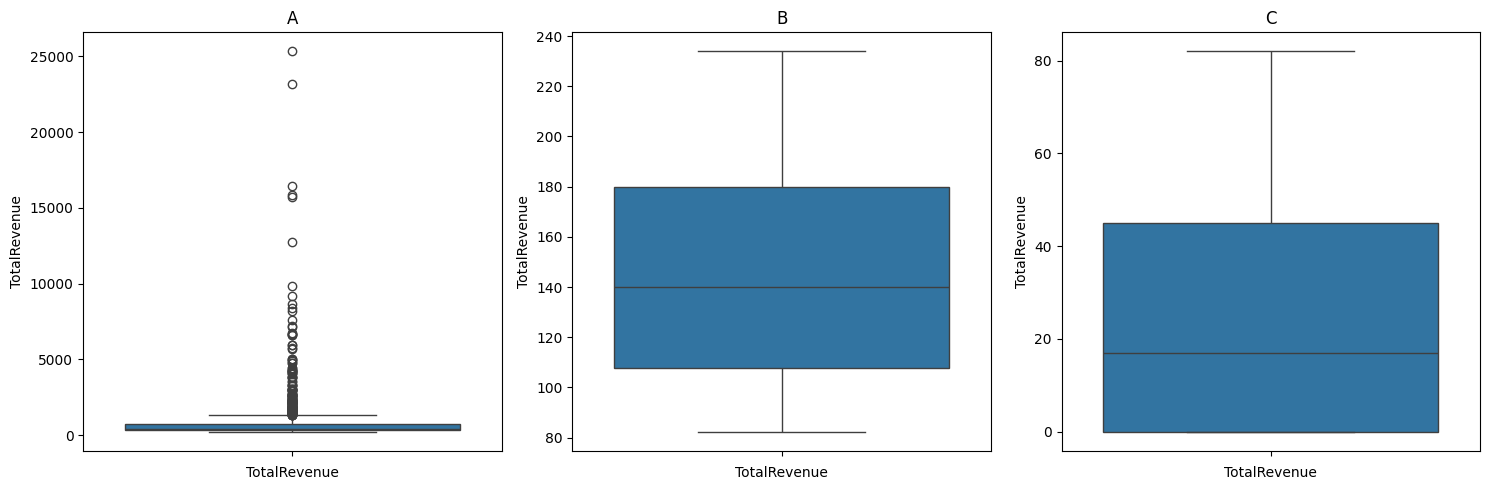

In [53]:
# Box plot: ABC Category
import matplotlib.pyplot as plt
import seaborn as sns

categories = ['A', 'B', 'C']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for i, cat in enumerate(categories):
    data = store_summary[store_summary['ABC_Category'] == cat]

    sns.boxplot(
        y=data['TotalRevenue'],
        ax=axes[i]
    )

    axes[i].set_title(f'{cat}')
    axes[i].set_xlabel('TotalRevenue')

plt.tight_layout()
plt.show()

## How Fast It Moves: Inventory Turnover Ratio & FSN Analysis



> Inventory turnover ratio is the amount of time that passes from the day an item is purchased by a company until it is sold. A higher ratio is more desirable than a low one as a high ratio tends to point to strong sales.



In [54]:
# Calculate inventory turnover ratio
import numpy as np
# 1. Average Inventory
store_summary['AvgInv'] = (store_summary['BeginInvValue'] + store_summary['EndInvValue']) / 2

# 2. Inventory Turnover Ratio
store_summary['ITR'] = (store_summary['TotalCOGS'] / store_summary['AvgInv']).replace([np.inf, -np.inf], np.nan)

# Show statistical descriptive
store_summary['ITR'].describe()

,ITR
count,6091.000000
mean,0.837422
std,2.393048
min,0.000000
25%,0.091849
50%,0.400000
75%,1.031554
max,120.000000


> Fast-Slow-Non (FSN) analysis is an inventory management technique which divides goods based on how fast they are used or sold and how long they stay in storage.

FSN classification is determined using cumulative consumption rate (CR) and average stay:

Based on consumption rate,
* Fast-moving (F): up to 70%
* Slow-moving (S): 70%–90%
* Non-moving (N): above 90%

Based on average stay,
* Non-moving (N): up to 70%
* Slow-moving (S): 70%–90%
* Fast-moving (F): above 90%

In [55]:
# Fast-Slow-Non Moving Analysis: Part 1
# 1. Calculate consumption rate
# Consumption Rate
fsn = store_summary.copy()
fsn['CR'] = fsn['TotalSalesQuantity'] / 31

# 2. Calculate average stay
fsn['AvgStay'] = 31 / (fsn['BeginInv'] + fsn['TotalPurchaseQuantity'])

# 3. Calculate Cumulative Sum & Percentage Cumsum CR
cr = fsn.copy().sort_values(by='CR', ascending=False)
cr['CumulativeCR'] = cr['CR'].cumsum()
cr['PercentageCumulativeCR'] = cr['CumulativeCR'] / cr['CR'].sum()

# 4. Calculate Cumulative Sum & Percentage Cumsum AvgStay
avg_stay = fsn.copy().sort_values(by='AvgStay', ascending=False)
avg_stay['CumulativeAvgStay'] = avg_stay['AvgStay'].cumsum()
avg_stay['PercentageCumulativeAvgStay'] = avg_stay['CumulativeAvgStay'] / avg_stay['AvgStay'].sum()

# Merge data
fsn = cr.merge(avg_stay)

In [56]:
# Fast-Slow-Non Moving Analysis: Part 2
# Define High-Medium-Low Consumption
def consumption_class(cr_pct):
    if (cr_pct <= 0.7):
        return 'F'
    elif (cr_pct > 0.7) and (cr_pct) <= 0.9:
        return 'S'
    else:
        return 'N'

fsn['ConsumptionClass'] = fsn['PercentageCumulativeCR'].apply(consumption_class)

# Define High-Medium-Low Stay
def stay_class(avgstay_pct):
    if (avgstay_pct <= 0.7):
        return 'N'
    elif (avgstay_pct > 0.7) and (avgstay_pct) <= 0.9:
        return 'S'
    else:
        return 'F'

fsn['StayClass'] = fsn['PercentageCumulativeAvgStay'].apply(stay_class)

# Define ConsumptionStayClass
fsn['ConsumptionStayClass'] = fsn['ConsumptionClass'] + '-' + fsn['StayClass']

# Define FSN category
fsn['FSN_Category'] = fsn['ConsumptionStayClass'].replace({
    'F-F': 'F', 'F-S': 'F', 'F-N': 'S', 'S-F': 'S', 'S-S': 'S',
    'S-N': 'N', 'N-F': 'N', 'N-S': 'N', 'N-N': 'N'})

# Show statistical descriptive
fsn_summary = fsn.groupby('FSN_Category').agg(
    Count=('TotalSalesQuantity', 'count'),
    minSalesQty=('TotalSalesQuantity', 'min'),
    maxSalesQty=('TotalSalesQuantity', 'max'),
    minCR=('CR', 'min'),
    maxCR=('CR', 'max'),
    minDIO=('AvgStay', 'min'),
    maxDIO=('AvgStay', 'max')
).reindex(['F','S','N'])

fsn_summary['Percentage'] = (fsn_summary['Count'] / fsn_summary['Count'].sum()) * 100
fsn_summary

,Count,minSalesQty,maxSalesQty,minCR,maxCR,minDIO,maxDIO,Percentage
FSN_Category,,,,,,,,
F,948,25,1055,0.806452,34.032258,0.016525,1.192308,15.209369
S,1306,9,25,0.290323,0.806452,0.102990,3.444444,20.952992
N,3979,0,9,0.000000,0.290323,0.171271,inf,63.837638


In [57]:
# Map store_summary to FSN class
store_summary['FSN_Category'] = store_summary['Brand'].map(fsn.set_index('Brand')['FSN_Category'])
store_summary['CR'] = store_summary['Brand'].map(fsn.set_index('Brand')['CR'])
store_summary['AvgStay'] = store_summary['Brand'].map(fsn.set_index('Brand')['AvgStay'])

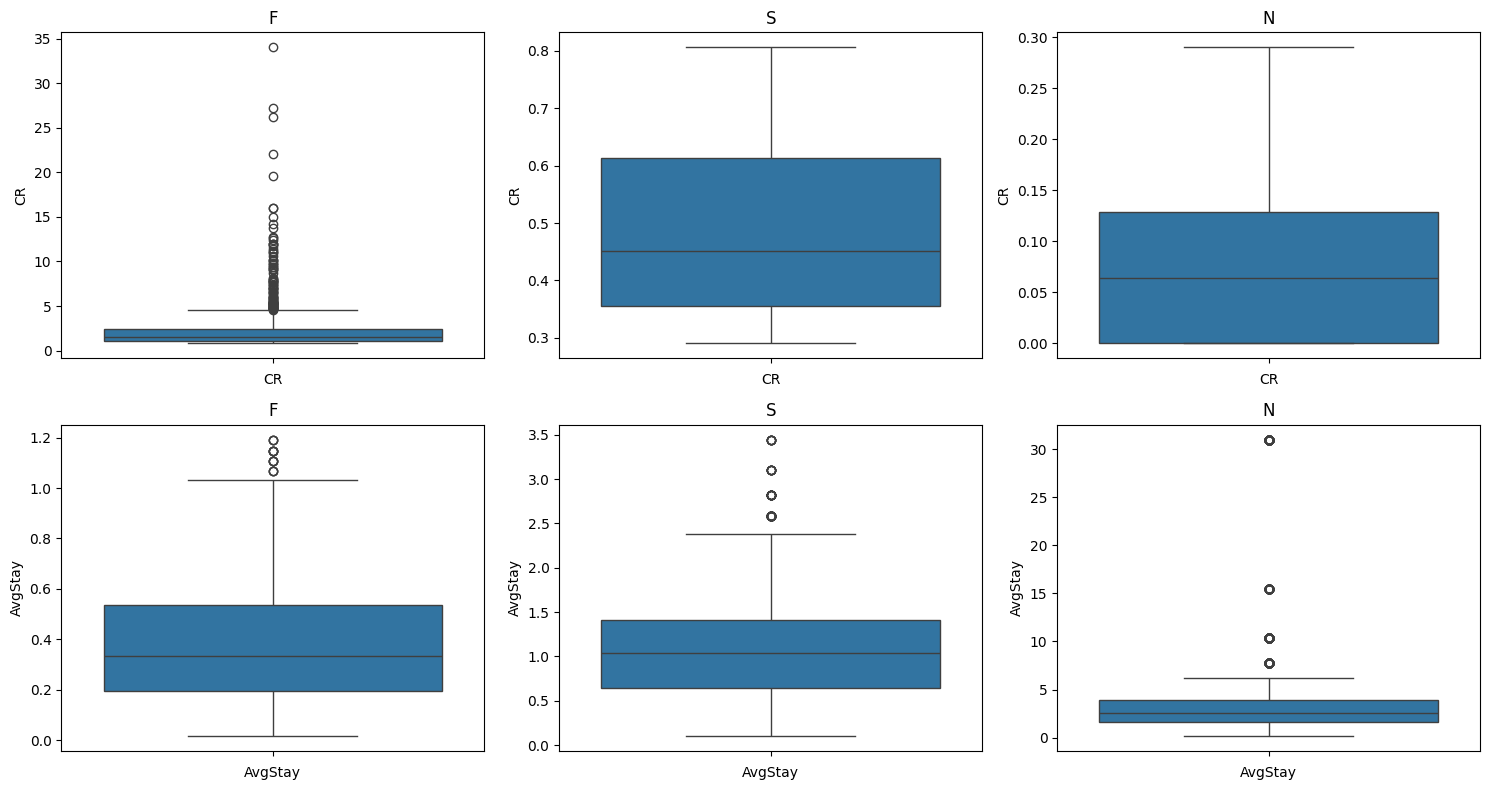

In [58]:
# Box plot: FSN Category
categories = ['F', 'S', 'N']

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)

for i, cat in enumerate(categories):
    data = store_summary[store_summary['FSN_Category'] == cat]

    # Row 1 → CR
    sns.boxplot(
        y='CR',
        data=data,
        ax=axes[0, i]
    )
    axes[0, i].set_title(f'{cat}')
    axes[0, i].set_xlabel('CR')

    # Row 2 → AvgStay
    sns.boxplot(
        y='AvgStay',
        data=data,
        ax=axes[1, i]
    )
    axes[1, i].set_title(f'{cat}')
    axes[1, i].set_xlabel('AvgStay')

plt.tight_layout()
plt.show()

In [59]:
# Build ABC x FSN matrix
abc_fsn = store_summary.groupby(['ABC_Category', 'FSN_Category']).agg(Count=('Brand', 'count'))
abc_fsn

Count
ABC_Category FSN_Category       
A            F               831
             N               176
             S               517
B            F                96
             N               761
             S               728
C            F                21
             N              3042
             S                61

## How Long It Lasts: Days of Supply



> Days of supply is the number of days it would take your supply to run out if not replenished.



In [60]:
# Calculate average demand
store_summary['AvgDemand'] = store_summary['TotalSalesQuantity'] / 31

# Calculate days of supply
store_summary['DOS'] = store_summary['EndInv'] / store_summary['AvgDemand']

## When to Act: Reorder Point



> Reorder point is the signal when to place a new order to avoid stock-outs.

We define target service levels for each ABC–FSN segment as follows:
* Class A-F: 98%
* Class A-S: 95%
* Class B-F: 96%
* Class B-S: 93%
* Class C-F: 92%
* Class C-S: 90%
* Others (all N class): 80%


In [62]:
# Create lead time data
lead_time = purchase_store[['Brand', 'Description', 'Size', 'VendorNumber', 'PODate', 'ReceivingDate']].copy()

# Calculate lead time (days gap from pre-order date to receiving date)
lead_time['LeadTime'] = lead_time['ReceivingDate'] - lead_time['PODate']
lead_time['LeadTime'] = lead_time['LeadTime'].dt.days

# Aggregate by brand, description, and size
lead_time_agg = lead_time.groupby(['Brand', 'Description', 'Size']).agg(
    avgLeadTime = ('LeadTime', 'mean'),
    minLeadTime = ('LeadTime', 'min'),
    maxLeadTime = ('LeadTime', 'max'),
    stdLeadTime = ('LeadTime', 'std'))

lead_time_agg['stdLeadTime'] = lead_time_agg['stdLeadTime'].fillna(
    lead_time_agg['avgLeadTime'] * 0.2)

lead_time_agg = lead_time_agg.reset_index()
lead_time_agg

,Brand,Description,Size,avgLeadTime,minLeadTime,maxLeadTime,stdLeadTime
0,58,Gekkeikan Black & Gold Sake,750mL,5.500000,5,6,0.707107
1,62,Herradura Silver Tequila,750mL,7.000000,7,7,1.400000
2,77,Three Olives Espresso Vodka,750mL,11.000000,11,11,2.200000
3,79,Three Olives Loopy Vodka,750mL,6.000000,5,7,1.414214
4,115,Belvedere Vodka,1000mL,8.571429,4,12,2.699206
...,...,...,...,...,...,...,...
2916,46985,Rodney Strong Cab Svgn Alexa,750mL,6.500000,4,9,3.535534
2917,47027,Marcus James Malbec Mendoza,1500mL,11.000000,11,11,2.200000
2918,47075,Turn Me Red,750mL,7.000000,7,7,1.400000
2919,47090,Napa Cellars Cab Svgn Napa,750mL,8.666667,5,12,3.511885


In [64]:
# Calculate safety stock
def get_service_level(row):
    abc = row['ABC_Category']
    fsn = row['FSN_Category']

    if abc == 'A' and fsn == 'F':
        return 0.98
    elif abc == 'A' and fsn == 'S':
        return 0.95
    elif abc == 'B' and fsn == 'F':
        return 0.96
    elif abc == 'B' and fsn == 'S':
        return 0.93
    elif abc == 'C' and fsn == 'F':
        return 0.92
    elif abc == 'C' and fsn == 'S':
        return 0.90
    else:  # Non-moving (N)
        return 0.80

store_summary['ServiceLevel'] = store_summary.apply(get_service_level, axis=1)

from scipy.stats import norm

store_summary['Z'] = store_summary['ServiceLevel'].apply(lambda x: norm.ppf(x))
store_summary['SafetyStock'] = store_summary['Z'] * store_summary['Brand'].map(lead_time_agg.set_index('Brand')['stdLeadTime'])

# Calculate reorder point
store_summary['ROP'] = (store_summary['AvgDemand'] * store_summary['Brand'].map(lead_time_agg.set_index('Brand')['avgLeadTime'])) + store_summary['SafetyStock']

# Define reorder status
def ro(current_inv, rop):
  if current_inv < rop:
    return 'Reorder'
  else:
    return 'No Reorder'

# Apply reorder status
store_summary['ReorderStatus'] = store_summary.apply(lambda x: ro(x['EndInv'], x['ROP']), axis=1)

In [100]:
# Save to csv file
store_summary.to_csv('14_PITMERDEN-SummaryJan16.csv', index=False)

Index(['StoreId', 'Brand', 'Description', 'Size', 'BeginInv', 'BeginInvValue',
       'TotalSalesQuantity', 'TotalRevenue', 'TotalCOGS', 'TotalProfit',
       'TotalPurchaseQuantity', 'TotalPurchaseCost', 'TotalDemandUnfulfilled',
       'EndInv', 'EndInvValue', 'AvgInv', 'ITR', 'ABC_Category',
       'FSN_Category', 'CR', 'AvgStay', 'ServiceLevel', 'Z', 'SafetyStock',
       'AvgDemand', 'DOS', 'ROP', 'ReorderStatus'],
      dtype='object')